In [115]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [116]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    
     

In [117]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [118]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama3-8b-8192")


In [119]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8E1625090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8E15B07D0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [120]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")

In [121]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8E15D4AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8E15D7550>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [122]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [123]:
graph_builder= StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph=graph_builder.compile()

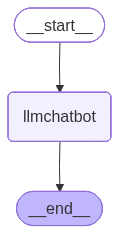

In [124]:
graph

In [125]:
response = graph.invoke({"messages":"hi"})

In [126]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [127]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [128]:
from time import time
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2,time_range="week")
tool.invoke("what is langgraph")

"No search results found for 'what is langgraph'. Suggestions: Try a general search using 'general' topic. Try modifying your search parameters with one of these approaches."

In [ ]:
@tool
def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a:first int
        b:second int

    Returns:
        int:output int
    """
    return a*b
    

In [155]:
tools=[tool,multiply]

In [156]:
# llm_with_tool=llm.bind_tools(tools)

llm_with_tool=llm.bind_tools(tools)

In [132]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8E15D4AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8E15D7550>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [133]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
    return{"messages":[llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)

builder.add_edge("tools",END)

graph= builder.compile()




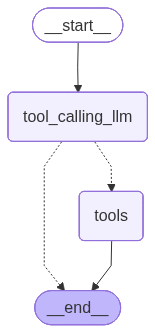

In [134]:
graph

In [135]:
response=graph.invoke({"messages":"what is the recent ai news"})

In [136]:
response

{'messages': [HumanMessage(content='what is the recent ai news', additional_kwargs={}, response_metadata={}, id='e0501f2c-4cf7-4e3e-a874-50672341eb8f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'drn4agpqh', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1751, 'total_tokens': 1782, 'completion_time': 0.106969338, 'completion_tokens_details': None, 'prompt_time': 0.092727694, 'prompt_tokens_details': None, 'queue_time': 0.056298965, 'total_time': 0.199697032}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-9756-7e21-9533-253b9506d043-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'time_range': 'day', 'topic': 'n

In [137]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/202251-figma-adds-ai-agent-to-its-design-platform.html", "title": "Фигма ўзининг дизайн платформасига сунъий интеллект агентини қўшди - Zamin.uz", "score": 0.97754294, "published_date": "Wed, 20 May 2026 13:27:19 GMT", "content": "# Figma adds AI agent to its design platform. In recent months, Figma has partnered with OpenAI and Anthropic, enabling users to leverage coding environments like Claude Code and Codex alongside its design software. Now, the company has introduced a new AI agent that operates within its collaborative canvas. The company emphasizes that this AI assistant understands design context and elements well, as it is powered by AI models specifically tailored for the design industry. The new agent will initially launch on the Figma Design platform and will be integrated into the company\'s other products in the future. Despite conc

In [138]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (drn4agpqh)
 Call ID: drn4agpqh
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/202251-figma-adds-ai-agent-to-its-design-platform.html", "title": "Фигма ўзининг дизайн платформасига сунъий интеллект агентини қўшди - Zamin.uz", "score": 0.97754294, "published_date": "Wed, 20 May 2026 13:27:19 GMT", "content": "# Figma adds AI agent to its design platform. In recent months, Figma has partnered with OpenAI and Anthropic, enabling users to leverage coding environments like Claude Code and Codex alongside its design so

In [139]:
response=graph.invoke({"messages":"what is 5 multiplied by 7"})

for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

what is 5 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multiply (1xd4kccc6)
 Call ID: 1xd4kccc6
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: multiply

35


In [140]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (g4nxqenq8)
 Call ID: g4nxqenq8
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
    topic: news
  multiply (fh3dx232c)
 Call ID: fh3dx232c
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/202251-figma-adds-ai-agent-to-its-design-platform.html", "title": "Фигма ўзининг дизайн платформасига сунъий интеллект агентини қўшди - Zamin.uz", "score": 0.9666631, "published_date": "Wed, 20 May 2026 13:27:19 GMT", "content": "# Figma adds AI agent to its design platform. In recent months, Figma has partnered with 

In [141]:
response=graph.invoke({"messages":"hello my name is Harsh"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is Harsh
================================== Ai Message ==================================

Hello Harsh, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [142]:
response=graph.invoke({"messages":"what is my name"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


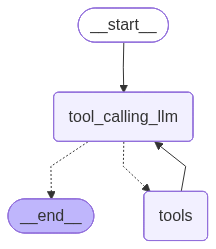

In [143]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state:State):
    return{"messages":[llm_with_tool.invoke(state["messages"])]}

builder= StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges("tool_calling_llm",tools_condition)

builder.add_edge("tools","tool_calling_llm")

graph=builder.compile(checkpointer=memory)

graph





In [144]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Harsh"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Harsh', additional_kwargs={}, response_metadata={}, id='e6aa6a36-6b84-4d7f-bcce-6c976dd88b20'),
  AIMessage(content="Hello Harsh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.066990552, 'completion_tokens_details': None, 'prompt_time': 0.097501111, 'prompt_tokens_details': None, 'queue_time': 0.050911208, 'total_time': 0.164491663}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-abc7-71f1-89ec-722241f31147-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778})]}

In [145]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Harsh.


In [146]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name, it's Harsh.


STREAMING


In [147]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [148]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

graph = StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

graph



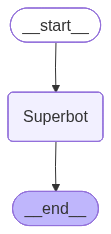

In [149]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [150]:
config={"configurable":{"thread_id":"1"}}

graph_builder.invoke({'messages':"hi, my name is harsh and i like cricket"},config)



{'messages': [HumanMessage(content='hi, my name is harsh and i like cricket', additional_kwargs={}, response_metadata={}, id='ad9f994b-4021-460f-8154-306d4c573e21'),
  AIMessage(content="Hi Harsh, nice to meet you. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Are you more into international cricket or do you follow domestic leagues like the IPL?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 45, 'total_tokens': 89, 'completion_time': 0.169943022, 'completion_tokens_details': None, 'prompt_time': 0.001934466, 'prompt_tokens_details': None, 'queue_time': 0.058620224, 'total_time': 0.171877488}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-cab3-7331-9167-b379cc146789-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'outpu

In [151]:
config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':'hi, my name is harsh and i like cricket'},config):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hi Harsh, nice to meet you. Cricket is a fantastic sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 45, 'total_tokens': 96, 'completion_time': 0.155078772, 'completion_tokens_details': None, 'prompt_time': 0.001228976, 'prompt_tokens_details': None, 'queue_time': 0.160117253, 'total_time': 0.156307748}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-cc23-7e61-8630-6dc52a431cd3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 51, 'total_tokens': 96})]}}


In [152]:
for chunk in graph_builder.stream({'messages':'hi, my name is harsh and i like football'},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi, my name is harsh and i like cricket', additional_kwargs={}, response_metadata={}, id='0ec16e2c-5f75-4e60-8671-453b27a12ffe'), AIMessage(content="Hi Harsh, nice to meet you. Cricket is a fantastic sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 45, 'total_tokens': 96, 'completion_time': 0.155078772, 'completion_tokens_details': None, 'prompt_time': 0.001228976, 'prompt_tokens_details': None, 'queue_time': 0.160117253, 'total_time': 0.156307748}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-cc23-7e61-8630-6dc52a431cd3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens':

In [153]:
config={"configurable":{"thread_id":"5"}}

for chunk in graph_builder.stream({'messages':'hi my name is Harsh and i like cricket'},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Nice to meet you, Harsh. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test cricket, One-Day Internationals, or T20?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.150631981, 'completion_tokens_details': None, 'prompt_time': 0.004229335, 'prompt_tokens_details': None, 'queue_time': 0.161380954, 'total_time': 0.154861316}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-cf91-7b13-b5a6-8296f8533536-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 56, 'total_tokens': 101})]}}


In [154]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is Harsh and i like cricket', additional_kwargs={}, response_metadata={}, id='dba45eef-5bfb-4696-9750-0a1a03a12235'), AIMessage(content='Nice to meet you, Harsh. Cricket is an exciting sport with a huge following worldwide. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test cricket, One-Day Internationals, or T20?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.150631981, 'completion_tokens_details': None, 'prompt_time': 0.004229335, 'prompt_tokens_details': None, 'queue_time': 0.161380954, 'total_time': 0.154861316}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e621e-cf91-7b13-b5a6-8296f8533536-0', tool_calls=[], invalid_tool_calls=[], usage_met